# Figure 4 — strain-level structure across lifestyles

| Panel | Content |
| --- | --- |
| **a** | Average nGD and polymorphism rate per SGB, Westernized against non-Westernized |
| **b** | Single- vs multi-strain sample-SGB dyads as a function of the coverage cutoff |
| **c** | Multi-strain rate per SGB, paired between lifestyles |
| **d** | SGBs tested per family, and the share with a significant phylogenetic signal |
| **e** | *Roseburia faecis* (SGB4925) tree — **not produced here**, see below |
| **f, g** | Average nGD and fold change, significant vs non-significant SGBs |
| **h** | anpan effect size against transmissibility |
| **S10a-c** | nGD and polymorphism by lifestyle, and the relation between them |
| **S11** | Transmissibility of the significant SGBs against the rest |

The analysis that ties the figure together is **anpan**: for each SGB it compares a phylogenetic
generalised linear mixed model of lifestyle against a base model without the phylogeny. An SGB where
the phylogenetic model wins is one whose strain tree carries lifestyle information — the strains a
person carries differ systematically between Westernized and non-Westernized hosts. "Significant"
throughout the figure means that comparison favoured the phylogenetic model (section 2).

Panels a, f and g then ask whether those SGBs are also more diverse or more polymorphic; b and c ask
whether non-Westernized hosts carry more strains at once; d asks which families the signal sits in;
h asks whether the signal is explained by how transmissible the SGB is.

**Panel e** is a StrainPhlAn tree annotated with lifestyle and continent. It is not rebuilt in this
notebook — the trees are in `./data/strainphlan_results.zip`, and the figure was drawn from
`RAxML_bestTree.t__SGB4925.StrainPhlAn3.tre` in that archive with an external tree viewer.

## 0. Setup

Several inputs are read off the cluster. The expensive steps — parsing the anpan job logs and
reading one StrainPhlAn result file per sample — are cached to TSV; delete a cache file to recompute.

In [1]:
import os
import re
from glob import iglob

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.genmod.families as families
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu, spearmanr
from tqdm import tqdm

BASE = '../data/nw_metanalysis'
DATA_DIR = '/shares/CIBIO-Storage/CM/scratch/data/meta'
SGB_DB = '../data/SGB.Jan21.txt.bz2'
MERGED_SGBS = '../data/Jan21_merged_sgbs.csv'

METADATA = '../data/nw_metadata.tsv'
CLADES = '../data/strainphlan/print_clades_only.txt'     # which samples each SGB was profiled in
ANPAN_LOGS = f'../scripts/anpan_analysis/anpan/SGB*.o'              # one job log per SGB
DISTANCES = '../data/nw_distances_final.tsv'             # per-SGB nGD summary, precomputed
POLYMORPHISMS = '../data/nw_poly_final.tsv'              # per-SGB polymorphism summary, precomputed
TRANSMISSION = '../data/transmission_rates_sgb.tsv'      # Valles-Colomer et al. 2023
SPA_VERSION = 'strainphlan-4.1.0_vJan21_CHOCOPhlAnSGB_202103-multi-strain'

CACHE_ANPAN = './cache_anpan_models.tsv'
CACHE_MULTISTRAIN = './cache_multistrain_results.tsv'
FIGURES = '../fig'

MIN_AGE = 16
EXCLUDED_STUDIES = ['HanniganGD_2017']
ANPAN_PREVALENCE = 0.05          # an SGB must reach this prevalence in both lifestyles
MULTISTRAIN_PREVALENCE = 0.10    # the same idea, for the multi-strain result files
COVERAGE_THRESHOLD = 10          # median coverage a sample-SGB dyad needs for a strain call
MIN_DYADS_PER_LIFESTYLE = 20     # an SGB needs this many dyads in each lifestyle
ELPD_THRESHOLD = -4              # how much better the phylogenetic model must be
MAX_PERC_BAD = 5                 # percentage of bad Pareto k values tolerated
FDR_THRESHOLD = 0.05
NGD_ALTERNATIVE = 'less'         # one-sided test used for panels f and g, as in the original

W_COLOR = '#2b8cbe'
NW_COLOR = '#e8e81e'
NS_COLOR = '#c0c0c0'
DIRECTION_COLORS = {'Higher Westernized': W_COLOR, 'Higher non-Westernized': NW_COLOR,
                    'Non-significant': NS_COLOR}
SINGLE_COLOR = '#8da0cb'
MULTI_COLOR = '#fc8d62'
BOX_W, BOX_NW = '#397797', '#d5d53e'
SIG_COLOR, NONSIG_COLOR = '#154360', '#6e2c00'

sns.set_theme(context='paper', style='whitegrid', font='DejaVu Sans')
mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'axes.labelweight': 'bold', 'legend.frameon': False,
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

## 1. Metadata and the SGBs worth testing

`print_clades_only.txt` lists, for every SGB, the samples StrainPhlAn could profile it in. An SGB
enters the anpan analysis only if it was profiled in at least 5% of the samples of **both**
lifestyles — otherwise the two trees being compared are not really comparable.

In [2]:
metadata = pd.read_table(METADATA).set_index('sample_id', drop=False)

lifestyle_counts = metadata['non_westernized'].value_counts()


def profiled_samples(path):
    """{SGB: [n Westernized, n non-Westernized]} from the StrainPhlAn clade listing."""
    counts = {}
    with open(path) as handle:
        for line in handle:
            if 't__SGB' not in line:
                continue
            sgb = line.strip().split('t__')[1].split(':')[0]
            samples = line.strip().split('[')[1].split(']')[0].replace("'", '').split(', ')
            lifestyles = metadata.reindex(samples)['non_westernized']
            counts[sgb] = [(lifestyles == 'no').sum(), (lifestyles == 'yes').sum()]
    return counts


profiled = profiled_samples(CLADES)
anpan_sgbs = [sgb for sgb, (w, nw) in profiled.items()
              if w / lifestyle_counts['no'] >= ANPAN_PREVALENCE
              and nw / lifestyle_counts['yes'] >= ANPAN_PREVALENCE]

print(f'{len(profiled):,} SGBs profiled, {len(anpan_sgbs):,} above '
      f'{ANPAN_PREVALENCE:.0%} prevalence in both lifestyles')

2,139 SGBs profiled, 124 above 5% prevalence in both lifestyles


## 2. anpan model comparisons

Each anpan job writes a log holding a `loo` comparison of the two models and the Pareto k diagnostics
of the fit. The parser below pulls out four things per SGB:

* which model won (`phylo` or `base`),
* `DiffModels`, the expected log predictive density difference — more negative is a stronger win for
  the phylogenetic model, so the effect size plotted in panel h is its negative,
* `SE` of that difference, and `DiffSE = 2*SE + DiffModels`, which is below zero when the difference
  clears two standard errors,
* the share of bad Pareto k values, which flags fits whose comparison should not be trusted.

An SGB counts as **significant** when the phylogenetic model wins by more than 4 elpd units, that
win clears two standard errors, and no more than 5% of the Pareto k values are bad.

In [3]:
def parse_anpan_log(path):
    """One anpan job log: which model won, by how much, and the Pareto k counts."""
    record = dict(BestModel=pd.NA, DiffModels=pd.NA, SE=pd.NA,
                  Good=pd.NA, Ok=pd.NA, Bad=pd.NA, VeryBad=pd.NA)
    with open(path) as handle:
        for line in handle:
            if line.strip().startswith('Pareto k diagnostic values'):
                handle.readline()
                for key, label in (('Good', '(good)'), ('Ok', '(ok)'),
                                   ('Bad', '(bad)'), ('VeryBad', '(very bad)')):
                    record[key] = int(handle.readline().split(label)[1].strip().split(' ')[0])
                break
            if line.strip().startswith('elpd_diff'):
                winner, second = handle.readline().strip(), handle.readline().strip()
                record['DiffModels'] = -float(second.split('-')[1].split(' ')[0]) if '-' in second else 0.0
                record['SE'] = float(second.split(' ')[-1])
                record['BestModel'] = 'phylo' if winner.startswith('pglmm_fit') else 'base'
    return record


def load_anpan_results(cache=CACHE_ANPAN):
    if os.path.exists(cache):
        return pd.read_table(cache, index_col=0)
    rows = {os.path.basename(path)[:-2]: parse_anpan_log(path)
            for path in iglob(ANPAN_LOGS) if 'nocountry' not in path}
    table = pd.DataFrame(rows).T
    table.index.name = 'SGBID'
    table.to_csv(cache, sep='\t')
    return table


anpan = load_anpan_results().reindex(anpan_sgbs)
for column in ('DiffModels', 'SE', 'Good', 'Ok', 'Bad', 'VeryBad'):
    anpan[column] = pd.to_numeric(anpan[column], errors='coerce')

anpan['DiffSE'] = 2 * anpan['SE'] + anpan['DiffModels']
anpan['PercBad'] = 100 * (anpan['Bad'] + anpan['VeryBad']) / anpan[['Good', 'Ok', 'Bad', 'VeryBad']].sum(axis=1)
anpan['Samples'] = anpan[['Good', 'Ok', 'Bad', 'VeryBad']].sum(axis=1)

anpan['sig'] = ((anpan['BestModel'] == 'phylo') & (anpan['DiffModels'] < ELPD_THRESHOLD)
                & (anpan['DiffSE'] < 0) & (anpan['PercBad'] <= MAX_PERC_BAD))

# Effect size: positive when the phylogenetic model is the better one.
anpan['EffectSize'] = np.where(anpan['BestModel'] == 'phylo', -anpan['DiffModels'],
                               anpan['DiffModels'])

significant_sgbs = anpan.index[anpan['sig']].tolist()
print(f"{anpan['BestModel'].notna().sum()} SGBs with a model comparison, "
      f'{len(significant_sgbs)} significant')
anpan.sort_values('EffectSize', ascending=False).head()

122 SGBs with a model comparison, 25 significant


,BestModel,DiffModels,SE,Good,Ok,Bad,VeryBad,DiffSE,PercBad,Samples,sig,EffectSize
SGBID,,,,,,,,,,,,
SGB5117,phylo,-1467.8,119.6,2239.0,14.0,11.0,5.0,-1228.6,0.705156,2269.0,True,1467.8
SGB4925,phylo,-1444.6,470.5,5205.0,12.0,2.0,3.0,-503.6,0.095749,5222.0,True,1444.6
SGB4581,phylo,-1028.5,273.2,4333.0,9.0,10.0,5.0,-482.1,0.344274,4357.0,True,1028.5
SGB4290,phylo,-922.4,207.4,1560.0,14.0,7.0,8.0,-507.6,0.943990,1589.0,True,922.4
SGB4933_group,phylo,-864.4,287.1,7288.0,57.0,26.0,28.0,-290.2,0.729828,7399.0,True,864.4


## 3. nGD and polymorphism summaries

Two precomputed tables, one row per SGB: the average and median normalised phylogenetic distance
between strains within each lifestyle, and the same for the polymorphism rate, each with a
lifestyle comparison already tested and FDR-corrected. `NW_FDR` and `W_FDR` are the one-sided
versions, which is what gives each SGB its direction in panel a.

In [4]:
def read_sgb_summary(path):
    table = pd.read_table(path, sep=',', index_col=0)
    table.index = [sgb[3:] for sgb in table.index]       # drop the t__ prefix
    return table


distances = read_sgb_summary(DISTANCES)
polymorphisms = read_sgb_summary(POLYMORPHISMS)


def direction(table, nw_fdr='NW_FDR', w_fdr='W_FDR'):
    """Label each SGB by which lifestyle it is significantly higher in."""
    labels = pd.Series('Non-significant', index=table.index)
    labels[table[nw_fdr] < FDR_THRESHOLD] = 'Higher non-Westernized'
    labels[table[w_fdr] < FDR_THRESHOLD] = 'Higher Westernized'
    return labels


distances['direction'] = direction(distances)
polymorphisms['direction'] = direction(polymorphisms)

pd.DataFrame({'nGD': distances['direction'].value_counts(),
              'polymorphisms': polymorphisms['direction'].value_counts()})

,nGD,polymorphisms
Higher Westernized,102,96
Higher non-Westernized,174,137
Non-significant,59,114


## 4. Panel a — nGD and polymorphism, Westernized against non-Westernized

One point per SGB on log axes, with the identity line for reference: a point above the line is an
SGB whose strains are more diverse in non-Westernized hosts.

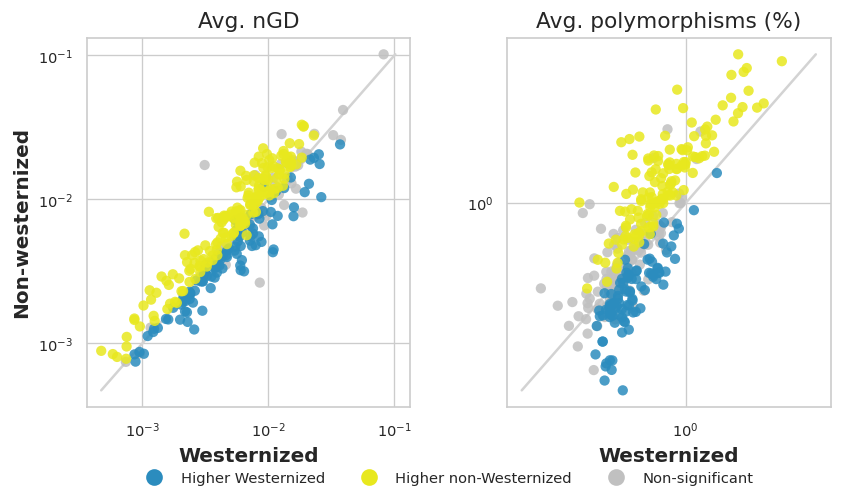

In [5]:
def plot_lifestyle_scatter(ax, table, x, y, title):
    for label, color in DIRECTION_COLORS.items():
        subset = table[table['direction'] == label]
        ax.scatter(subset[x], subset[y], s=38, c=color, alpha=0.85,
                   edgecolors='none', label=label, zorder=3 if label != 'Non-significant' else 2)

    limits = [min(table[x].min(), table[y].min()), max(table[x].max(), table[y].max())]
    ax.plot(limits, limits, color='lightgrey', linewidth=1.5, zorder=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Westernized')
    ax.set_ylabel('Non-westernized')
    ax.set_title(title)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'wspace': 0.3})
plot_lifestyle_scatter(axes[0], distances, 'W_avg_dist', 'NW_avg_dist', 'Avg. nGD')
plot_lifestyle_scatter(axes[1], polymorphisms, 'W_avg_poly', 'NW_avg_poly',
                       'Avg. polymorphisms (%)')
axes[1].set_ylabel('')

fig.legend(handles=[Line2D([], [], marker='o', linestyle='', markersize=9, color=color, label=label)
                    for label, color in DIRECTION_COLORS.items()],
           loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.show()

## 5. Panels b and c — multi-strain detection

StrainPhlAn's multi-strain mode writes one result file per sample, with a row per SGB holding its
median coverage and whether more than one strain was detected.

The SGB filter here is its own: present in more than 10% of the samples of both lifestyles, counted
from these result files rather than from the clade listing of section 1.

In [11]:
adult_meta = metadata[metadata['age'].notna() & (metadata['age'] != '1.083.333.333')].copy()
adult_meta['age'] = adult_meta['age'].astype(float)
adult_meta = adult_meta[(adult_meta['age'] > MIN_AGE)
                        & (~adult_meta['study_name'].isin(EXCLUDED_STUDIES))]

dyads = pd.read_table("../data/sample_sgb_dyads_strainphlan.tsv")

# SGBs seen in more than 10% of the samples of both lifestyles.
seen = dyads.groupby('non_westernized')['sgb_id'].value_counts().reset_index(name='count')
seen['prevalence'] = seen['count'] / seen['non_westernized'].map(adult_meta['non_westernized'].value_counts())
enough = seen[seen['prevalence'] > MULTISTRAIN_PREVALENCE]['sgb_id'].value_counts()
multistrain_sgbs = list(enough[enough == 2].index)

dyads = dyads[dyads['sgb_id'].isin(multistrain_sgbs)]
print(f'{len(dyads):,} sample-SGB dyads across {len(multistrain_sgbs)} SGBs')

dyads.head()

753,869 sample-SGB dyads across 318 SGBs


,sgb_id,n_markers_present,n_positions_total,coverage_25th,coverage_50th,coverage_75th,perc_positions_outlier_covered,n_markers_outlier_covered,n_positions_retained,n_markers_retained,...,snp_rate_var_ut,r_fit_var_ut,fit_method,pred_recall,pred_precision,pred_precision_support,output_minor_strain,study_name,sample_id,non_westernized
0,t__SGB10068,59,43254,8.0,14.0,20.0,0.049075,2,41444,57,...,8.665706e-07,0.000011,BFGS,0.571053,0.5,4.0,False,NielsenHB_2014,O2_UC51_0,no
10,t__SGB14247,199,140435,2.0,4.0,6.0,0.012970,0,137874,199,...,3.851345e-08,0.000223,Newton-CG,0.057565,0.0,0.0,False,NielsenHB_2014,O2_UC51_0,no
11,t__SGB14250,173,57779,2.0,2.0,2.0,0.000365,0,57708,173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NielsenHB_2014,O2_UC51_0,no
12,t__SGB14252,60,12563,2.0,2.0,2.0,0.000072,0,12558,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NielsenHB_2014,O2_UC51_0,no
13,t__SGB14263,75,13377,2.0,2.0,2.0,0.000107,0,13369,75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NielsenHB_2014,O2_UC51_0,no


Panel b is the argument for the 10x cutoff: below it the multi-strain fraction moves with coverage,
because a shallow profile cannot resolve a second strain. Above it the split is flat, so what is
left is a property of the sample rather than of its depth.

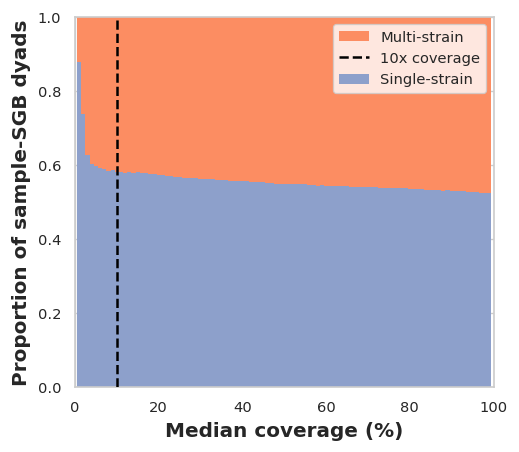

In [12]:
coverage_cutoffs = range(1, 100)
saturation = pd.DataFrame([
    {'coverage_cutoff': cutoff,
     'multi_strain_rate': dyads.loc[dyads['coverage_50th'] >= cutoff, 'multi_strain'].mean()}
    for cutoff in coverage_cutoffs])
saturation['single_strain_rate'] = 1 - saturation['multi_strain_rate']

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(saturation['coverage_cutoff'], saturation['single_strain_rate'], width=1.0,
       color=SINGLE_COLOR, edgecolor='none', label='Single-strain')
ax.bar(saturation['coverage_cutoff'], saturation['multi_strain_rate'], width=1.0,
       bottom=saturation['single_strain_rate'], color=MULTI_COLOR, edgecolor='none',
       label='Multi-strain')
ax.axvline(COVERAGE_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'{COVERAGE_THRESHOLD}x coverage', zorder=3)

ax.set_xlabel('Median coverage (%)')
ax.set_ylabel('Proportion of sample-SGB dyads')
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
handles, labels = ax.get_legend_handles_labels()
ax.legend([handles[2], handles[0], handles[1]], [labels[2], labels[0], labels[1]],
          loc='upper right', frameon=True)
plt.show()

Panel c pairs each SGB between the two lifestyles. The p-value comes from a GEE logit of the
per-dyad strain call, clustered on SGB, so that an SGB contributing many dyads does not count as
many independent observations, with coverage kept in the model since it still varies above the
cutoff.

In [13]:
usable = dyads[dyads['coverage_50th'] > COVERAGE_THRESHOLD]
per_lifestyle = usable.groupby('sgb_id')['non_westernized'].value_counts().reset_index(name='count')
paired_sgbs = per_lifestyle.groupby('sgb_id').filter(
    lambda group: len(group) == 2 and (group['count'] > MIN_DYADS_PER_LIFESTYLE).all())
usable = usable[usable['sgb_id'].isin(paired_sgbs['sgb_id'].unique())].reset_index(drop=True)

usable['multi_strain_int'] = usable['multi_strain'].astype(int)
gee = smf.gee('multi_strain_int ~ C(non_westernized) + coverage_50th', groups='sgb_id',
              data=usable, family=families.Binomial()).fit()
gee_pvalue = gee.pvalues['C(non_westernized)[T.yes]']

multi_strain_rates = (usable.groupby(['sgb_id', 'non_westernized'])['multi_strain']
                      .mean().rename('multi_strain_rate').reset_index())
multi_strain_rates['lifestyle'] = multi_strain_rates['non_westernized'].map({'no': 'W', 'yes': 'NW'})

print(f'{usable["sgb_id"].nunique()} SGBs, GEE p = {gee_pvalue:.2e}')
print(gee.summary().tables[1])

114 SGBs, GEE p = 5.23e-05
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.3562      0.150     -2.382      0.017      -0.649      -0.063
C(non_westernized)[T.yes]     0.5787      0.143      4.045      0.000       0.298       0.859
coverage_50th                 0.0005      0.000      1.579      0.114      -0.000       0.001


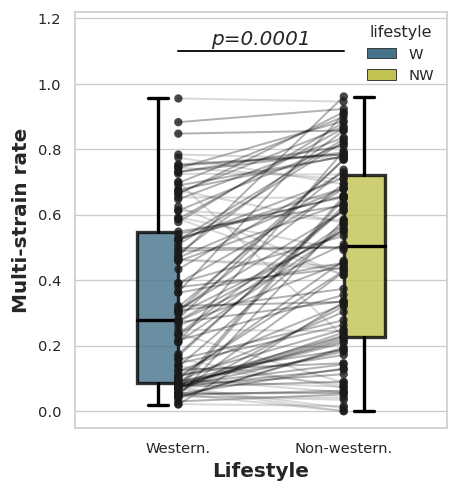

In [18]:
paired = multi_strain_rates.pivot(index='sgb_id', columns='lifestyle',
                                  values='multi_strain_rate').dropna(subset=['W', 'NW'])

fig, ax = plt.subplots(figsize=(4, 4.5))
for _, row in paired.iterrows():
    ax.plot([0, 1], [row['W'], row['NW']], color='black' if row['NW'] >= row['W'] else 'gray',
            alpha=0.3, linewidth=1.2, zorder=2)

box_style = dict(data=multi_strain_rates, x='lifestyle', y='multi_strain_rate', order=['W', 'NW'])
sns.boxplot(**box_style, hue='lifestyle', palette={'W': BOX_W, 'NW': BOX_NW},
            width=0.5, fliersize=0, ax=ax, zorder=1,
            boxprops=dict(alpha=0.8, edgecolor='black', linewidth=2),
            whiskerprops=dict(color='black', linewidth=2),
            capprops=dict(color='black', linewidth=2),
            medianprops=dict(color='black', linewidth=2))
sns.stripplot(**box_style, color='k', size=5, alpha=0.8, jitter=0.001, ax=ax, zorder=3, dodge=True)

ax.plot([0, 1], [1.1, 1.1], c='k', linewidth=1.2)
ax.text(0.5, 1.12, f'p={gee_pvalue:.4f}', ha='center', fontsize=12, style='italic')
ax.set_ylim(-0.05, 1.22)
ax.set_xlabel('Lifestyle')
ax.set_ylabel('Multi-strain rate')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Western.', 'Non-western.'])
plt.show()

## 6. Panel d — which families carry the signal

Every tested SGB is assigned its family from the MetaRefSGB release, and families are kept if they
were tested more than once or contain at least one significant SGB. The left bar is how many SGBs of
that family were tested at all, the right bar the share of them that came out significant — a family
can reach 100% on a single SGB, which is why both bars are shown.

In [19]:
def sgb_taxonomy(path):
    """{SGB id: {rank: name}} from the MetaRefSGB release file."""
    table = pd.read_csv(path, sep='\t', skiprows=[0, 1, 2, 3])
    table = table[table['# Label'] == 'SGB'].set_index('ID')
    ranks = table['Assigned taxonomy'].str.split('|').apply(
        lambda lineage: {clade[:1]: clade[3:] for clade in lineage})
    return ranks.to_dict()


def pretty_family(name):
    return name.replace('_unclassified', ' uncl.')


taxonomy = sgb_taxonomy(SGB_DB)
tested = anpan[anpan['BestModel'].notna()].copy()
tested['family'] = [taxonomy[int(sgb[3:].split('_')[0])]['f'] for sgb in tested.index]

families_table = tested.groupby('family').agg(Total=('sig', 'size'), Count=('sig', 'sum'))
families_table['Percentage'] = 100 * families_table['Count'] / families_table['Total']
families_table = families_table[(families_table['Total'] > 1) | (families_table['Count'] > 0)]
families_table = families_table.sort_values('Total')
families_table.index = [pretty_family(name) for name in families_table.index]

families_table

,Total,Count,Percentage
Akkermansiaceae,1,1,100.000000
Firmicutes uncl.,1,1,100.000000
Peptostreptococcaceae,1,1,100.000000
Bacteroidales uncl.,2,0,0.000000
Rikenellaceae,2,0,0.000000
Streptococcaceae,2,2,100.000000
Tannerellaceae,2,0,0.000000
Clostridiaceae,3,0,0.000000
Erysipelotrichaceae,3,0,0.000000
Prevotellaceae,4,1,25.000000


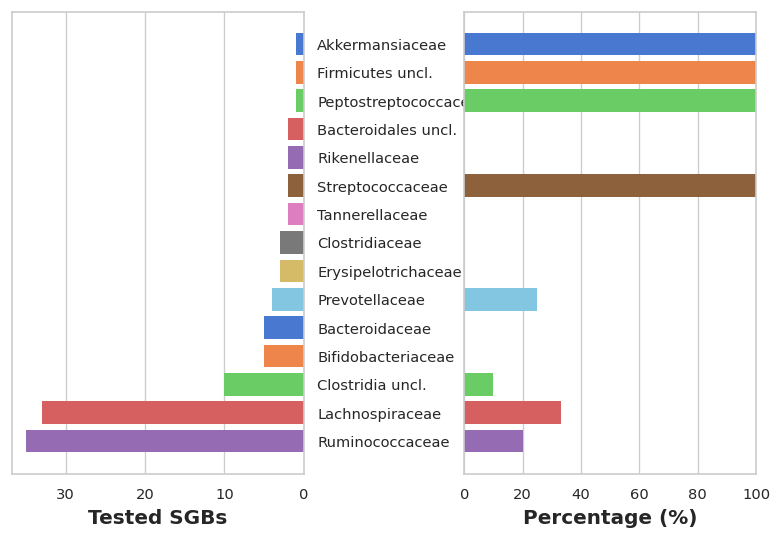

In [21]:
palette = sns.color_palette('muted', len(families_table))
y = np.arange(len(families_table))

fig, (ax_total, ax_perc) = plt.subplots(1, 2, figsize=(8, 5), sharey=True,
                                        gridspec_kw={'wspace': 0.55})

ax_total.barh(y, families_table['Total'], color=palette, edgecolor='none')
ax_total.invert_xaxis()                      # bars grow to the left, towards the labels
ax_total.set_xlabel('Tested SGBs')

ax_perc.barh(y, families_table['Percentage'], color=palette, edgecolor='none')
ax_perc.set_xlabel('Percentage (%)')
ax_perc.set_xlim(0, 100)

ax_total.set_yticks(y)
ax_total.set_yticklabels(families_table.index)
ax_total.invert_yaxis()                      # fewest tested SGBs at the top
ax_total.tick_params(axis='y', length=0, labelleft=False, labelright=True, pad=8)
for ax in (ax_total, ax_perc):
    ax.grid(axis='y', b=False)
plt.show()

## 7. Panels f and g — are the significant SGBs the diverse ones?

A natural worry about panel a: maybe anpan finds lifestyle structure only in the SGBs that have a
lot of strain diversity to begin with. These panels check it directly, comparing the significant
SGBs against the rest on average nGD within each lifestyle, and on the fold change between
lifestyles. The test is the one-sided Mann-Whitney used in the original (`NGD_ALTERNATIVE`), asking
whether the significant SGBs sit *lower*.

{'nS': 97, 'S': 25}


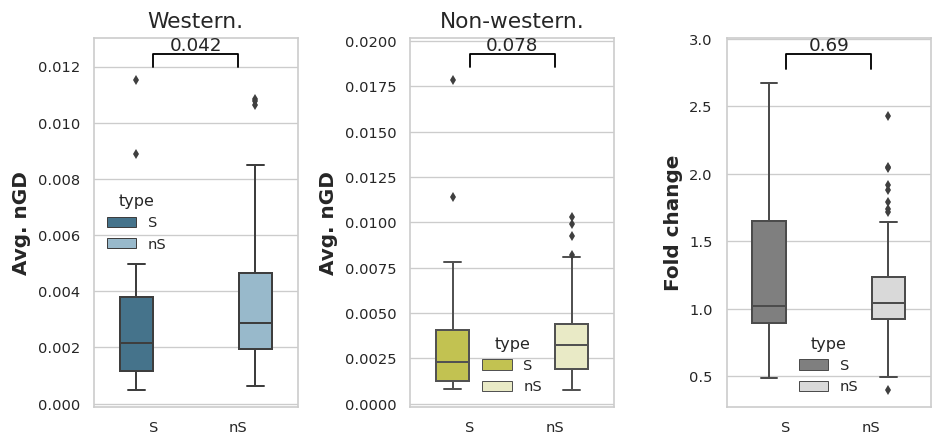

In [23]:
def significance_groups(table, sgbs=None):
    """Label the rows of a per-SGB table as significant or not, dropping untested SGBs."""
    tested_index = [sgb for sgb in (sgbs if sgbs is not None else tested.index)
                    if sgb in table.index]
    labelled = table.loc[tested_index].copy()
    labelled['type'] = np.where(labelled.index.isin(significant_sgbs), 'S', 'nS')
    return labelled


def box_with_pvalue(ax, frame, column, ylabel, colors, title=None,
                    alternative=NGD_ALTERNATIVE):
    groups = frame.groupby('type')[column]
    pvalue = mannwhitneyu(groups.get_group('S'), groups.get_group('nS'),
                          alternative=alternative).pvalue

    sns.boxplot(data=frame, x='type', y=column, order=['S', 'nS'], hue='type',
                hue_order=['S', 'nS'], palette=colors,  linewidth=1.2,
                flierprops={'marker': 'd', 'markersize': 4, 'markerfacecolor': '#3f3f3f',
                            'markeredgecolor': 'none'}, ax=ax)

    top = frame[column].max()
    ax.plot([0, 0, 1, 1], [top * 1.04, top * 1.08, top * 1.08, top * 1.04], lw=1.1, color='black')
    ax.text(0.5, top * 1.08, f'{pvalue:.2g}', ha='center', va='bottom', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    return pvalue


ngd = significance_groups(distances)
print(ngd['type'].value_counts().to_dict())

fig, axes = plt.subplots(1, 3, figsize=(9, 4), gridspec_kw={'wspace': 0.55})
box_with_pvalue(axes[0], ngd, 'W_avg_dist', 'Avg. nGD',
                {'S': BOX_W, 'nS': '#8fbcd4'}, title='Western.')
box_with_pvalue(axes[1], ngd, 'NW_avg_dist', 'Avg. nGD',
                {'S': BOX_NW, 'nS': '#eff0c0'}, title='Non-western.')
box_with_pvalue(axes[2], ngd, 'fold_change', 'Fold change',
                {'S': '#7f7f7f', 'nS': '#d9d9d9'})
# fig.savefig(f'{FIGURES}/Figure4fg.svg')
plt.show()

## 8. Panel h — effect size against transmissibility

The other natural worry: a strongly transmissible SGB is passed between people who live together,
so its tree would track households and communities, and lifestyle with them. If that drove the
anpan result, effect size would rise with transmissibility.

Matching the transmissibility table to this dataset's SGB ids needs the Jan21 merge table, because
some SGBs were merged between releases; two ids are remapped by hand, as in the original. SGBs the
transmission paper flagged as food-derived are then excluded, since their sharing between people
reflects a shared diet rather than transmission.

In [24]:
MANUAL_REMAP = {'15317': '15316', '8007': '8002'}
FOOD_SGBS = ['SGB7088', 'SGB7144', 'SGB8002_group', 'SGB10068', 'SGB17247', 'SGB17248',
             'SGB10115_group', 'SGB17278']


def read_merge_groups(path):
    """Each line lists the SGB ids that were merged into one."""
    groups = []
    with open(path) as handle:
        handle.readline()
        for line in handle:
            head, members = line.strip().split(';')
            groups.append([head[3:]] + members.split(','))
    return groups


def transmission_key(sgb, available, merge_groups):
    """The id this SGB is called in the transmission table, or None."""
    base = sgb.replace('SGB', '').replace('_group', '')
    for old, new in MANUAL_REMAP.items():
        base = base.replace(old, new)
    candidates = next((group for group in merge_groups if base in group), [base])
    for candidate in candidates:
        for key in (f'SGB{candidate}', f"SGB{candidate.split('_')[0]}", f'SGB{candidate}_group'):
            if key in available:
                return key
    return None


transmission = pd.read_table(TRANSMISSION, index_col=0)
merge_groups = read_merge_groups(MERGED_SGBS)

keys = {sgb: transmission_key(sgb, set(transmission.index), merge_groups) for sgb in anpan_sgbs}
unmatched = [sgb for sgb, key in keys.items() if key is None]
print(f'{len(keys) - len(unmatched)} SGBs matched, {len(unmatched)} unmatched: {unmatched}')

matched = pd.DataFrame({sgb: transmission.loc[key] for sgb, key in keys.items() if key}).T
anpan_transmission = matched.join(anpan[['sig', 'EffectSize']], how='inner')

# Drop the food-derived SGBs, following the whole merge group of each.
food_keys = {transmission_key(sgb, set(transmission.index), merge_groups) for sgb in FOOD_SGBS}
is_food = [keys[sgb] in food_keys for sgb in anpan_transmission.index]
anpan_transmission = anpan_transmission[~np.array(is_food)]

print(f'{len(anpan_transmission)} SGBs plotted, {sum(is_food)} food-derived SGBs dropped')
anpan_transmission.head()

115 SGBs matched, 9 unmatched: ['SGB4837_group', 'SGB14546_group', 'SGB4563_group', 'SGB1871', 'SGB4262', 'SGB15368', 'SGB15053_group', 'SGB5765_group', 'SGB8071']
112 SGBs plotted, 3 food-derived SGBs dropped


,SGB_mother-infant_transmissibility,SGB_household_transmissibility,SGB_intradataset_transmissibility,sig,EffectSize
SGB4933_group,0.280000,0.105033,0.019616,True,864.4
SGB1836_group,0.729323,0.196581,0.023868,False,89.7
SGB1814,0.697479,0.242105,0.076939,False,-0.4
SGB4874,0.250000,0.078795,0.021058,False,21.3
SGB15316_group,0.103448,NaN,NaN,False,-0.4


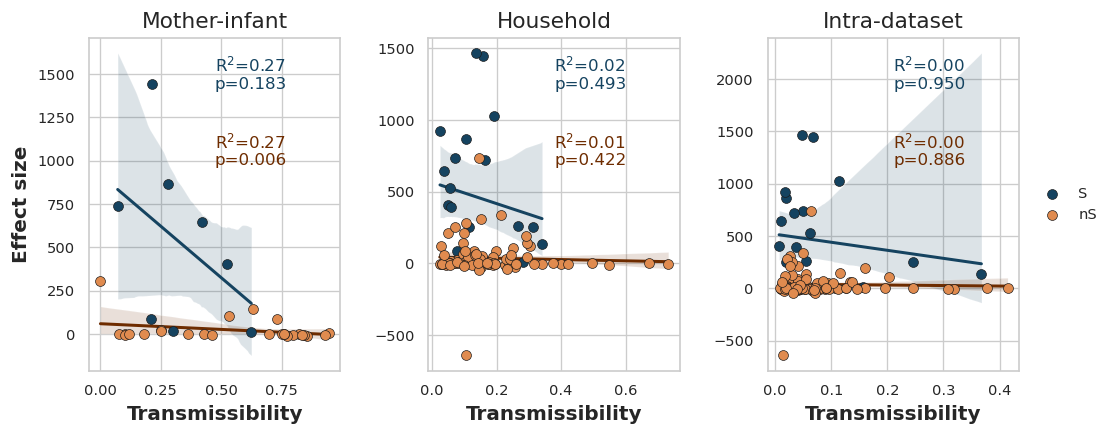

In [25]:
SCENARIOS = [('SGB_mother-infant_transmissibility', 'Mother-infant'),
             ('SGB_household_transmissibility', 'Household'),
             ('SGB_intradataset_transmissibility', 'Intra-dataset')]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6), sharey=False,
                         gridspec_kw={'wspace': 0.35})

for ax, (column, title) in zip(axes, SCENARIOS):
    for flag, color, label in ((True, SIG_COLOR, 'S'), (False, NONSIG_COLOR, 'nS')):
        subset = anpan_transmission[anpan_transmission['sig'] == flag]
        sns.regplot(data=subset, x=column, y='EffectSize', ax=ax, scatter=False, color=color)
        ax.scatter(subset[column], subset['EffectSize'], edgecolor='k', linewidths=0.4,
                   s=35, color=color if flag else '#e08b4f', label=label, zorder=3)

        valid = subset[[column, 'EffectSize']].dropna()
        r, p = spearmanr(valid[column], valid['EffectSize'])
        ax.text(0.5, 0.95 if flag else 0.72, f'R$^2$={r ** 2:.2f}\np={p:.3f}',
                transform=ax.transAxes, color=color, ha='left', va='top', fontsize=10)

    ax.set_title(title)
    ax.set_xlabel('Transmissibility')
    ax.set_ylabel('Effect size' if ax is axes[0] else '')

axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.show()

## 9. Panel e — the *Roseburia faecis* tree

Not rebuilt here. The StrainPhlAn output, including the RAxML trees for every SGB and graphlan images, is archived in
`./data/strainphlan_results.zip`

## 10. Figure S10

In [26]:
from scipy.stats import pearsonr, wilcoxon

S10_PAIRED = True

ngd_poly = distances[['W_avg_dist', 'NW_avg_dist']].join(
    polymorphisms[['W_avg_poly', 'NW_avg_poly']], how='inner').dropna()

S10_METRICS = [('Avg. nGD', 'W_avg_dist', 'NW_avg_dist'),
               ('Avg. polymorphisms (%)', 'W_avg_poly', 'NW_avg_poly')]


def lifestyle_comparison(table, w_column, nw_column, paired=S10_PAIRED):
    """Long-form values for one metric, plus the lifestyle p-value."""
    long = pd.concat([
        pd.DataFrame({'value': table[w_column], 'lifestyle': 'Western.'}),
        pd.DataFrame({'value': table[nw_column], 'lifestyle': 'Non-western.'})])
    if paired:
        pvalue = wilcoxon(table[w_column], table[nw_column]).pvalue
    else:
        pvalue = mannwhitneyu(table[w_column], table[nw_column],
                              alternative='two-sided').pvalue
    return long, pvalue


print(f'{len(ngd_poly)} SGBs with both measures')
ngd_poly.describe().T[['mean', '50%', 'max']]

335 SGBs with both measures


,mean,50%,max
W_avg_dist,0.007825,0.006010,0.082124
NW_avg_dist,0.008937,0.006794,0.101650
W_avg_poly,0.657198,0.538994,3.323354
NW_avg_poly,0.892717,0.634049,5.076164


### Panels a and b

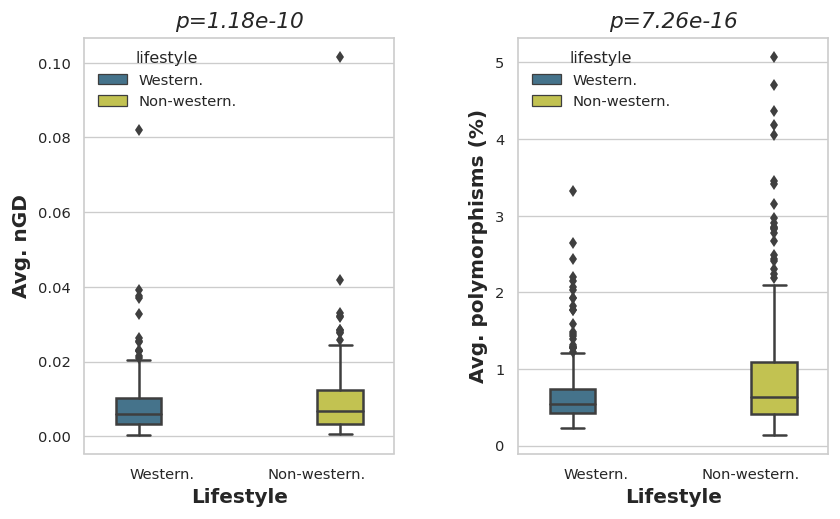

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4.5), gridspec_kw={'wspace': 0.4})

for ax, (label, w_column, nw_column) in zip(axes, S10_METRICS):
    long, pvalue = lifestyle_comparison(ngd_poly, w_column, nw_column)
    sns.boxplot(data=long, x='lifestyle', y='value', order=['Western.', 'Non-western.'],
                hue='lifestyle', hue_order=['Western.', 'Non-western.'],
                palette={'Western.': BOX_W, 'Non-western.': BOX_NW}, width=0.6, linewidth=1.5,
                flierprops={'marker': 'd', 'markersize': 5, 'markerfacecolor': '#3f3f3f',
                            'markeredgecolor': 'none'}, ax=ax)
    ax.set_title(f'p={pvalue:.2e}', style='italic')
    ax.set_xlabel('Lifestyle')
    ax.set_ylabel(label)
    ax.grid(axis='x', visible=False)
plt.show()

### Panel c

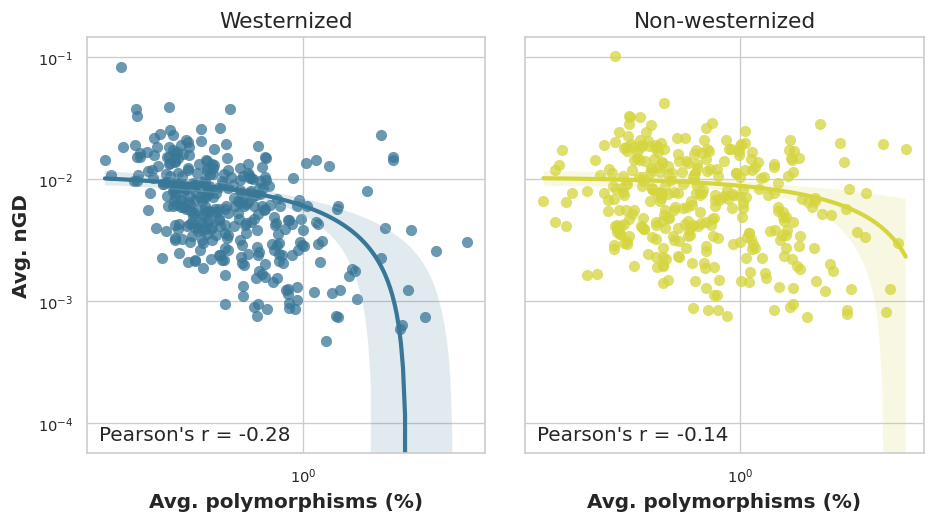

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True, gridspec_kw={'wspace': 0.1})

for ax, (title, color, x_column, y_column) in zip(axes, [
        ('Westernized', BOX_W, 'W_avg_poly', 'W_avg_dist'),
        ('Non-westernized', BOX_NW, 'NW_avg_poly', 'NW_avg_dist')]):
    sns.regplot(data=ngd_poly, x=x_column, y=y_column, ax=ax, color=color,
                scatter_kws={'s': 45, 'alpha': 0.75, 'linewidths': 0}, line_kws={'linewidth': 2.5})

    r, _ = pearsonr(ngd_poly[x_column], ngd_poly[y_column])
    ax.text(0.03, 0.03, f"Pearson's r = {r:.2f}", transform=ax.transAxes, fontsize=12)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(title)
    ax.set_xlabel('Avg. polymorphisms (%)')
    ax.set_ylabel('Avg. nGD' if ax is axes[0] else '')
plt.show()

## 11. Figure S11

In [34]:
DROP_FOOD = True
P_THRESHOLDS = [(1e-4, '1e-4'), (1e-3, '0.001'), (1e-2, '0.01'), (0.05, '0.05')]


def format_threshold_p(pvalue):
    """'p \u2264 0.01' at the tightest threshold the value clears, otherwise 'p = 0.13'."""
    for threshold, label in P_THRESHOLDS:
        if pvalue <= threshold:
            return f'p \u2264 {label}'
    return f'p = {pvalue:.2f}'


transmissibility = (anpan_transmission if DROP_FOOD
                    else matched.join(anpan[['sig']], how='inner'))
transmissibility = transmissibility.copy()
transmissibility[[column for column, _ in SCENARIOS]] *= 100        # rates -> percentages
transmissibility['anpan'] = np.where(transmissibility['sig'], 'significant', 'non-sig')

print(transmissibility['anpan'].value_counts().to_dict())
transmissibility.groupby('anpan')[[column for column, _ in SCENARIOS]].median()

{'non-sig': 90, 'significant': 22}


,SGB_mother-infant_transmissibility,SGB_household_transmissibility,SGB_intradataset_transmissibility
anpan,,,
non-sig,58.29932,14.785374,4.796272
significant,29.00000,10.933459,3.519857


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw={'wspace': 0.45})

for ax, (column, title) in zip(axes, SCENARIOS):
    groups = transmissibility.groupby('anpan')[column]
    pvalue = mannwhitneyu(groups.get_group('non-sig').dropna(),
                          groups.get_group('significant').dropna(),
                          alternative='two-sided').pvalue

    sns.boxplot(data=transmissibility, x='anpan', y=column, order=['non-sig', 'significant'],
                hue='anpan', hue_order=['non-sig', 'significant'],
                palette={'non-sig': 'tab:blue', 'significant': 'tab:orange'},
                width=0.7, linewidth=1.5,
                flierprops={'marker': 'd', 'markersize': 5, 'markerfacecolor': '#3f3f3f',
                            'markeredgecolor': 'none'}, ax=ax)

    top = transmissibility[column].max()
    ax.plot([0, 0, 1, 1], [top * 1.06, top * 1.11, top * 1.11, top * 1.06], lw=1.2, color='black',
            clip_on=False)
    ax.text(0.5, top * 1.13, f'M.W.W. {format_threshold_p(pvalue)}', ha='center', va='bottom',
            fontsize=12)

    ax.set_xlabel('Anpan test')
    ax.set_ylabel(f'{title} transmissibility (%)')
    ax.grid(axis='x', visible=False)
plt.show()